Cell 1 – Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings("ignore")

Cell 2 – Load Dataset

In [2]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Cell 3 – Dataset Information

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

Cell 4 – Statistical Summary

In [4]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,1237,1334,4,793,793,3,1,531,...,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5968,37,37,5191,9994,915,...,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
std,2885.163629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32063.693350,NaN,NaN,NaN,NaN,NaN,623.245101,2.225110,0.206452,234.260108
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000


Cell 5 – Missing Values

In [5]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


Cell 6 – Remove Duplicates

In [6]:
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates")
print(df.shape)

Dataset Shape After Removing Duplicates
(9994, 21)


Cell 7 – Convert Date Columns

In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Cell 8 – Feature Engineering

In [8]:
df["Shipping_Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df["Order_Month"] = df["Order Date"].dt.month

df["Order_Year"] = df["Order Date"].dt.year

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping_Days,Order_Month,Order_Year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,11,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,11,2016
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,6,2016
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,10,2015
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,10,2015


Cell 9 – Create Purchase Status

In [9]:
median_sales = df["Sales"].median()

df["Purchase_Status"] = np.where(
    df["Sales"] >= median_sales,
    1,
    0
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping_Days,Order_Month,Order_Year,Purchase_Status
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,11,2016,1
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,11,2016,1
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,6,2016,0
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,10,2015,1
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,10,2015,0


Cell 10 – Category Summary

In [10]:
category_summary = (
    df.groupby("Category")
      .agg(
          Total_Sales=("Sales","sum"),
          Average_Profit=("Profit","mean"),
          Orders=("Order ID","count")
      )
      .reset_index()
)

category_summary

,Category,Total_Sales,Average_Profit,Orders
0,Furniture,741999.7953,8.699327,2121
1,Office Supplies,719047.0320,20.327050,6026
2,Technology,836154.0330,78.752002,1847


Cell 11 – Region Summary

In [11]:
region_summary = (
    df.groupby("Region")
      .agg(
          Total_Sales=("Sales","sum"),
          Average_Profit=("Profit","mean"),
          Orders=("Order ID","count")
      )
      .reset_index()
)

region_summary

,Region,Total_Sales,Average_Profit,Orders
0,Central,501239.8908,17.092709,2323
1,East,678781.2400,32.135808,2848
2,South,391721.9050,28.857673,1620
3,West,725457.8245,33.849032,3203


Cell 12 – Region Category Summary

In [12]:
region_category_summary = (
    df.groupby(["Region","Category"])
      .agg(
          Sales=("Sales","sum"),
          Profit=("Profit","sum")
      )
      .reset_index()
)

region_category_summary

,Region,Category,Sales,Profit
0,Central,Furniture,163797.1638,-2871.0494
1,Central,Office Supplies,167026.4150,8879.9799
2,Central,Technology,170416.3120,33697.4320
3,East,Furniture,208291.2040,3046.1658
4,East,Office Supplies,205516.0550,41014.5791
5,East,Technology,264973.9810,47462.0351
6,South,Furniture,117298.6840,6771.2061
7,South,Office Supplies,125651.3130,19986.3928
8,South,Technology,148771.9080,19991.8314
9,West,Furniture,252612.7435,11504.9503


Cell 13 – Pivot Table

In [13]:
pivot_table = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

pivot_table

Category,Furniture,Office Supplies,Technology
Region,,,
Central,163797.1638,167026.415,170416.312
East,208291.2040,205516.055,264973.981
South,117298.6840,125651.313,148771.908
West,252612.7435,220853.249,251991.832


Cell 14 – Top Products

In [14]:
top_products = (
    df.groupby("Product Name")
      .agg(
          Total_Sales=("Sales","sum")
      )
      .sort_values(
          "Total_Sales",
          ascending=False
      )
      .head(10)
      .reset_index()
)

top_products


,Product Name,Total_Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


Cell 15 – Sales by Category Chart

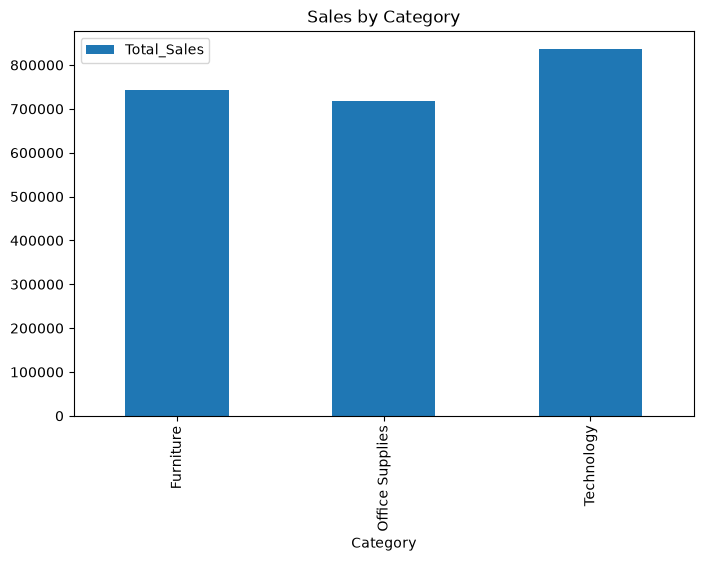

In [15]:
category_summary.plot(
    x="Category",
    y="Total_Sales",
    kind="bar",
    figsize=(8,5),
    title="Sales by Category"
)

plt.show()

Cell 16 – Sales by Region Chart

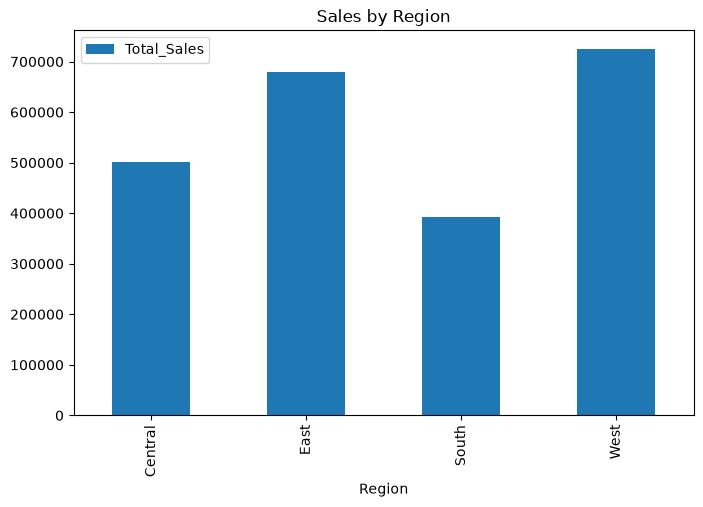

In [16]:
region_summary.plot(
    x="Region",
    y="Total_Sales",
    kind="bar",
    figsize=(8,5),
    title="Sales by Region"
)

plt.show()

Cell 17 – Sales vs Profit

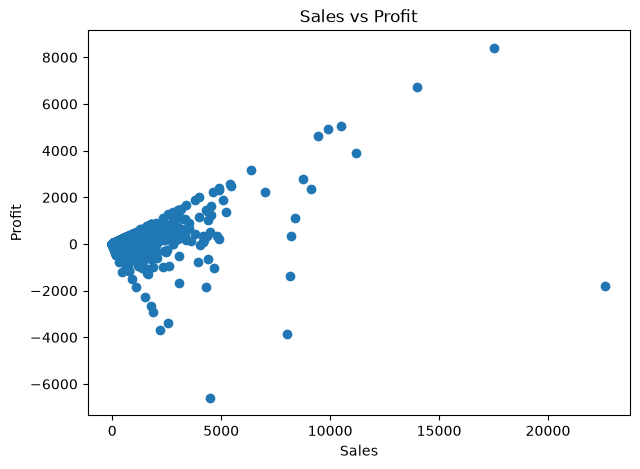

In [17]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["Sales"],
    df["Profit"]
)

plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")

plt.show()

Cell 18 – Label Encoding

In [18]:
encoder = LabelEncoder()

categorical_columns = [
    "Category",
    "Sub-Category",
    "Region",
    "Segment",
    "Ship Mode"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping_Days,Order_Month,Order_Year,Purchase_Status
0,1,CA-2016-152156,2016-11-08,2016-11-11,2,CG-12520,Claire Gute,0,United States,Henderson,...,4,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,11,2016,1
1,2,CA-2016-152156,2016-11-08,2016-11-11,2,CG-12520,Claire Gute,0,United States,Henderson,...,5,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,11,2016,1
2,3,CA-2016-138688,2016-06-12,2016-06-16,2,DV-13045,Darrin Van Huff,1,United States,Los Angeles,...,10,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,6,2016,0
3,4,US-2015-108966,2015-10-11,2015-10-18,3,SO-20335,Sean O'Donnell,0,United States,Fort Lauderdale,...,16,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,10,2015,1
4,5,US-2015-108966,2015-10-11,2015-10-18,3,SO-20335,Sean O'Donnell,0,United States,Fort Lauderdale,...,14,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,10,2015,0


Cell 19 – Regression Features

In [19]:
X_reg = df[
    [
        "Quantity",
        "Discount",
        "Shipping_Days",
        "Category",
        "Sub-Category",
        "Region"
    ]
]

y_reg = df["Sales"]

Cell 20 – Classification Features

In [20]:
X_cls = X_reg.copy()

y_cls = df["Purchase_Status"]

Cell 21 – Train Test Split

In [21]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42
)

Cell 22 – Feature Scaling

In [23]:
scaler = StandardScaler()

X_train_reg = scaler.fit_transform(X_train_reg)
X_test_reg = scaler.transform(X_test_reg)

X_train_cls = scaler.fit_transform(X_train_cls)
X_test_cls = scaler.transform(X_test_cls)

Cell 23 – Import ML Models

In [24]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    silhouette_score
)

Cell 24 – Linear Regression

In [25]:
linear_model = LinearRegression()

linear_model.fit(X_train_reg, y_train_reg)

reg_predictions = linear_model.predict(X_test_reg)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


Cell 25 – Regression Evaluation

In [26]:
mae = mean_absolute_error(y_test_reg, reg_predictions)

mse = mean_squared_error(y_test_reg, reg_predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test_reg, reg_predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 273.37625006095607
RMSE: 751.6012112610205
R2 Score: 0.04366822176341367


Cell 26 – Save Regression Predictions

In [27]:
regression_predictions = pd.DataFrame({
    "Actual_Sales": y_test_reg,
    "Predicted_Sales": reg_predictions
})

regression_predictions.head()

,Actual_Sales,Predicted_Sales
3125,563.808,280.933009
1441,36.672,86.474631
4510,37.300,131.988476
39,212.058,127.737650
4509,171.288,184.594016


Cell 27 – Logistic Regression

In [28]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_cls, y_train_cls)

cls_predictions = log_model.predict(X_test_cls)

cls_probability = log_model.predict_proba(X_test_cls)[:,1]

print("Logistic Regression Completed")

Logistic Regression Completed


Cell 28 – Classification Evaluation

In [29]:
accuracy = accuracy_score(y_test_cls, cls_predictions)

precision = precision_score(y_test_cls, cls_predictions)

recall = recall_score(y_test_cls, cls_predictions)

f1 = f1_score(y_test_cls, cls_predictions)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.5897948974487244
Precision: 0.5773195876288659
Recall : 0.5773195876288659
F1 Score : 0.5773195876288659


Cell 29 – Save Classification Predictions

In [30]:
classification_predictions = pd.DataFrame({

    "Actual": y_test_cls,

    "Predicted": cls_predictions,

    "Probability": cls_probability

})

classification_predictions.head()

,Actual,Predicted,Probability
3125,1,1,0.586437
1441,0,0,0.364453
4510,0,0,0.444573
39,1,0,0.390840
4509,1,1,0.515853


Cell 30 – K-Means Clustering

In [31]:
cluster_features = df[[
    "Sales",
    "Profit",
    "Quantity",
    "Discount"
]]

cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(cluster_features)

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(cluster_scaled)

df["Cluster"] = clusters

print("Clustering Completed")

Clustering Completed


Cell 31 – Silhouette Score

In [32]:
sil_score = silhouette_score(
    cluster_scaled,
    clusters
)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.36805387863934164


Cell 32 – Cluster Summary

In [33]:
cluster_summary = df.groupby("Cluster").agg({

    "Sales":"mean",

    "Profit":"mean",

    "Quantity":"mean"

})

cluster_summary

,Sales,Profit,Quantity
Cluster,,,
0,124.439315,14.337664,2.544343
1,6423.002812,2508.018009,5.343750
2,366.433292,51.037359,6.441335
3,3259.930966,-1782.624648,5.965517


Cell 33 – Hyperparameter Tuning

In [34]:
parameters = {

    "C":[0.01,0.1,1,10],

    "solver":["liblinear","lbfgs"]

}

grid = GridSearchCV(

    LogisticRegression(max_iter=1000),

    parameters,

    cv=5,

    scoring="accuracy"

)

grid.fit(X_train_cls, y_train_cls)

print("Best Parameters")

print(grid.best_params_)

print("Best Score")

print(grid.best_score_)

Best Parameters
{'C': 1, 'solver': 'lbfgs'}
Best Score
0.601125703564728


Cell 34 – Best Hyperparameters

In [35]:
best_parameters = pd.DataFrame({

    "Parameter":[str(grid.best_params_)],

    "Best Score":[grid.best_score_]

})

best_parameters

,Parameter,Best Score
0,"{'C': 1, 'solver': 'lbfgs'}",0.601126


Cell 35 – Model Comparison

In [36]:
model_comparison = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Logistic Regression",

        "KMeans"

    ],

    "Score":[

        r2,

        accuracy,

        sil_score

    ]

})

model_comparison

,Model,Score
0,Linear Regression,0.043668
1,Logistic Regression,0.589795
2,KMeans,0.368054


Cell 36 – Save Output Files

In [37]:
df.to_csv(

    "cleaned_superstore.csv",

    index=False

)

regression_predictions.to_csv(

    "regression_predictions.csv",

    index=False

)

classification_predictions.to_csv(

    "classification_predictions.csv",

    index=False

)

df[["Customer ID","Cluster"]].to_csv(

    "clustered_customers.csv",

    index=False

)

model_comparison.to_csv(

    "model_comparison.csv",

    index=False

)

best_parameters.to_csv(

    "best_hyperparameters.csv",

    index=False

)

category_summary.to_csv(

    "category_summary.csv",

    index=False

)

region_summary.to_csv(

    "region_summary.csv",

    index=False

)

region_category_summary.to_csv(

    "region_category_summary.csv",

    index=False

)

pivot_table.to_csv(

    "pivot_region_category.csv"

)

top_products.to_csv(

    "top_products.csv",

    index=False

)

print("All output files exported successfully.")

All output files exported successfully.


Cell 37 – Visualization

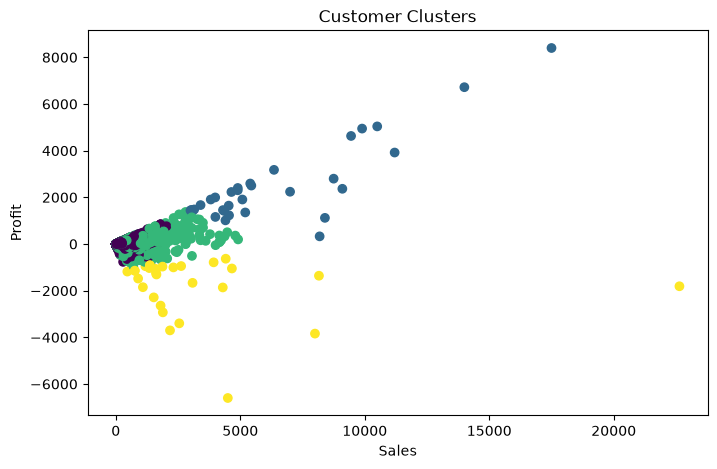

In [38]:
plt.figure(figsize=(8,5))

plt.scatter(

    df["Sales"],

    df["Profit"],

    c=df["Cluster"]

)

plt.xlabel("Sales")

plt.ylabel("Profit")

plt.title("Customer Clusters")

plt.show()

Cell 38 – Conclusion

In [39]:
print("="*50)

print("Task 6 Completed Successfully")

print("="*50)

print("Models Implemented:")

print("1. Linear Regression")

print("2. Logistic Regression")

print("3. K-Means Clustering")

print("4. Hyperparameter Tuning")

print()

print("Output Files Generated:")

print("- cleaned_superstore.csv")

print("- regression_predictions.csv")

print("- classification_predictions.csv")

print("- clustered_customers.csv")

print("- model_comparison.csv")

print("- best_hyperparameters.csv")

print("- category_summary.csv")

print("- region_summary.csv")

print("- region_category_summary.csv")

print("- pivot_region_category.csv")

print("- top_products.csv")

print()

print("Notebook Execution Completed Successfully!")

Task 6 Completed Successfully
Models Implemented:
1. Linear Regression
2. Logistic Regression
3. K-Means Clustering
4. Hyperparameter Tuning

Output Files Generated:
- cleaned_superstore.csv
- regression_predictions.csv
- classification_predictions.csv
- clustered_customers.csv
- model_comparison.csv
- best_hyperparameters.csv
- category_summary.csv
- region_summary.csv
- region_category_summary.csv
- pivot_region_category.csv
- top_products.csv

Notebook Execution Completed Successfully!
